In [3]:
# Cell 1 - Standard imports
import os
import sys
import random
import math
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Python:", sys.version if 'sys' in globals() else "unknown")
print("TensorFlow:", tf.__version__)





Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow: 2.18.0


In [4]:
# Cell 2 - Dataset paths and listings
TRAIN_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
TEST_DIR  = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("TEST_DIR exists:", os.path.exists(TEST_DIR))

# find classes from training dir
all_classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f"Found {len(all_classes)} classes (including del/nothing maybe):\n", all_classes)

# Exclude 'del' and 'nothing' (case-insensitive)
excluded = {'del', 'nothing'}
included_classes = [c for c in all_classes if c.lower() not in excluded]
excluded_present = [c for c in all_classes if c.lower() in excluded]
print("Excluded classes (will NOT be used):", excluded_present)
print("Included classes (training/validation):", included_classes)

TRAIN_DIR exists: True
TEST_DIR exists: True
Found 29 classes (including del/nothing maybe):
 ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Excluded classes (will NOT be used): ['del', 'nothing']
Included classes (training/validation): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'space']


In [5]:
# Cell 3 - Hyperparameters & Data Generators
IMG_SIZE = (227, 227)  # SqueezeNet expects 227x227 input
BATCH_SIZE = 32  # Increased batch size since SqueezeNet is smaller
SEED = 42
VALIDATION_SPLIT = 0.20

# Custom preprocessing function for SqueezeNet
def squeezenet_preprocess(img):
    # SqueezeNet typically uses ImageNet preprocessing
    # Convert RGB to BGR
    img = img[..., ::-1]
    # Subtract ImageNet mean
    img[..., 0] -= 103.939  # B mean
    img[..., 1] -= 116.779  # G mean
    img[..., 2] -= 123.68   # R mean
    return img

train_datagen = ImageDataGenerator(
    preprocessing_function=squeezenet_preprocess,
    validation_split=VALIDATION_SPLIT,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest',
    horizontal_flip=False
)

# flow_from_directory will only load directories listed in 'classes'
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=included_classes,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=included_classes,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {validation_generator.samples:,}")
print("Number of classes used:", len(train_generator.class_indices))
print("Class indices mapping (class -> index):\n", train_generator.class_indices)

Found 64800 images belonging to 27 classes.
Found 16200 images belonging to 27 classes.
Training samples: 64,800
Validation samples: 16,200
Number of classes used: 27
Class indices mapping (class -> index):
 {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'space': 26}


In [6]:
# Cell 4 - Build SqueezeNet model from scratch (since TF doesn't have pretrained SqueezeNet)
def fire_module(x, s1x1, e1x1, e3x3, name="fire"):
    """
    Fire module for SqueezeNet
    s1x1: number of 1x1 filters in squeeze layer
    e1x1: number of 1x1 filters in expand layer
    e3x3: number of 3x3 filters in expand layer
    """
    squeeze = layers.Conv2D(s1x1, (1, 1), padding='valid', activation='relu', name=f'{name}_squeeze')(x)
    
    expand1x1 = layers.Conv2D(e1x1, (1, 1), padding='valid', activation='relu', name=f'{name}_expand1x1')(squeeze)
    expand3x3 = layers.Conv2D(e3x3, (3, 3), padding='same', activation='relu', name=f'{name}_expand3x3')(squeeze)
    
    return layers.Concatenate(axis=-1, name=f'{name}_concat')([expand1x1, expand3x3])

def SqueezeNet(input_shape=(227, 227, 3), num_classes=1000, dropout_rate=0.5):
    """SqueezeNet v1.1 architecture (more efficient)"""
    inputs = keras.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='valid', activation='relu', name='conv1')(inputs)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool1')(x)
    
    # Fire modules
    x = fire_module(x, s1x1=16, e1x1=64, e3x3=64, name='fire2')
    x = fire_module(x, s1x1=16, e1x1=64, e3x3=64, name='fire3')
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool3')(x)
    
    x = fire_module(x, s1x1=32, e1x1=128, e3x3=128, name='fire4')
    x = fire_module(x, s1x1=32, e1x1=128, e3x3=128, name='fire5')
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool5')(x)
    
    x = fire_module(x, s1x1=48, e1x1=192, e3x3=192, name='fire6')
    x = fire_module(x, s1x1=48, e1x1=192, e3x3=192, name='fire7')
    x = fire_module(x, s1x1=64, e1x1=256, e3x3=256, name='fire8')
    x = fire_module(x, s1x1=64, e1x1=256, e3x3=256, name='fire9')
    
    # Final dropout and convolution
    x = layers.Dropout(dropout_rate, name='drop9')(x)
    x = layers.Conv2D(num_classes, (1, 1), padding='valid', activation='relu', name='conv10')(x)
    
    # Global pooling and softmax
    x = layers.GlobalAveragePooling2D(name='avgpool10')(x)
    outputs = layers.Activation('softmax', name='softmax')(x)
    
    return keras.Model(inputs, outputs, name='squeezenet')

# Load ImageNet pretrained weights if available, otherwise initialize randomly
num_classes = len(included_classes)

# Create base SqueezeNet with ImageNet classes
base_model = SqueezeNet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=1000, dropout_rate=0.5)

# Try to load pretrained weights
try:
    # Note: You might need to download pretrained weights for SqueezeNet
    # For now, we'll initialize randomly and train from scratch
    print("Training SqueezeNet from scratch (no pretrained weights loaded)")
except:
    print("Training SqueezeNet from scratch")

# Replace the final layer for our ASL classification task
# Get all layers except the last 3 (conv10, avgpool10, softmax)
base_output = base_model.layers[-4].output  # Get output before conv10

# Add new classification head for ASL
x = layers.Conv2D(num_classes, (1, 1), padding='valid', activation='relu', name='conv10_asl')(base_output)
x = layers.GlobalAveragePooling2D(name='avgpool10_asl')(x)
outputs = layers.Activation('softmax', name='softmax_asl')(x)

# Create final model
model = keras.Model(inputs=base_model.input, outputs=outputs, name="squeezenet_asl")

# Freeze early layers for initial training
for layer in model.layers[:-10]:  # Freeze all but last 10 layers
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


I0000 00:00:1765810713.082818      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765810713.083409      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training SqueezeNet from scratch (no pretrained weights loaded)


Model: "squeezenet_asl"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 227, 227,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 113, 113,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_squeeze       │ (None, 56, 56,    │      1,040 │ pool1[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_expand1x1     │ (None, 56, 56,    │      1,088 │ fire2_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_expand3x3     │ (None, 56, 56,    │      9,280 │ fire2_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_concat        │ (None, 56, 56,    │          0 │ fire2_expand1x1[… │
│ (Concatenate)       │ 128)              │            │ fire2_expand3x3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_squeeze       │ (None, 56, 56,    │      2,064 │ fire2_concat[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_expand1x1     │ (None, 56, 56,    │      1,088 │ fire3_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_expand3x3     │ (None, 56, 56,    │      9,280 │ fire3_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_concat        │ (None, 56, 56,    │          0 │ fire3_expand1x1[… │
│ (Concatenate)       │ 128)              │            │ fire3_expand3x3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 27, 27,    │          0 │ fire3_concat[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_squeeze       │ (None, 27, 27,    │      4,128 │ pool3[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_expand1x1     │ (None, 27, 27,    │      4,224 │ fire4_squeeze[0]… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_expand3x3     │ (None, 27, 27,    │     36,992 │ fire4_squeeze[0]… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_concat        │ (None, 27, 27,    │          0 │ fire4_expand1x1[… │
│ (Concatenate)       │ 256)              │            │ fire4_expand3x3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire5_squeeze       │ (None, 27, 27,    │      8,224 │ fire4_concat[0][

 Total params: 736,347 (2.81 MB)

 Trainable params: 358,747 (1.37 MB)

 Non-trainable params: 377,600 (1.44 MB)

In [7]:
# Cell 5 - F1 callback (uses sklearn)
!pip install -q scikit-learn >/dev/null 2>&1
from sklearn.metrics import f1_score, classification_report, confusion_matrix

class ValidationF1Callback(keras.callbacks.Callback):
    def __init__(self, val_generator):
        super().__init__()
        self.val_gen = val_generator
        self.f1s = []
    def on_epoch_end(self, epoch, logs=None):
        # predict on entire validation set
        y_prob = self.model.predict(self.val_gen, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        # get true labels
        if hasattr(self.val_gen, 'classes'):
            y_true = self.val_gen.classes
        else:
            # fallback: build labels from batches
            y_true = []
            for Xb, yb in self.val_gen:
                y_true.extend(np.argmax(yb, axis=1))
                if len(y_true) >= self.val_gen.samples:
                    break
            y_true = np.array(y_true[:self.val_gen.samples])
        f1 = f1_score(y_true, y_pred, average='macro')
        self.f1s.append(f1)
        print(f" — val_f1_macro: {f1:.4f}")

In [8]:
# Cell 6 - Stage 1: train top layers (base frozen)
EPOCHS_STAGE1 = 8  # Slightly more epochs since we're training from scratch

f1_callback = ValidationF1Callback(validation_generator)
checkpoint_cb = keras.callbacks.ModelCheckpoint("best_asl_squeezenet.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=validation_generator,
    callbacks=[f1_callback, checkpoint_cb, earlystop_cb, reduce_lr],
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8


I0000 00:00:1765810723.514892     122 service.cc:148] XLA service 0x7f693410c840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765810723.516657     122 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765810723.516677     122 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765810724.231600     122 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/2025 ━━━━━━━━━━━━━━━━━━━━ 4:57:28 9s/step - accuracy: 0.0312 - loss: 3.2937

I0000 00:00:1765810729.309017     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

 — val_f1_macro: 0.3298
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1199s 592ms/step - accuracy: 0.4364 - loss: 1.7876 - val_accuracy: 0.3346 - val_loss: 2.1824 - learning_rate: 0.0010
Epoch 5/8
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.5021 - loss: 1.5565

 — val_f1_macro: 0.3625
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1233s 609ms/step - accuracy: 0.5021 - loss: 1.5565 - val_accuracy: 0.3775 - val_loss: 2.1044 - learning_rate: 0.0010
Epoch 6/8
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5597 - loss: 1.3687

 — val_f1_macro: 0.3912
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1198s 591ms/step - accuracy: 0.5597 - loss: 1.3687 - val_accuracy: 0.3904 - val_loss: 2.0479 - learning_rate: 0.0010
Epoch 7/8
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6023 - loss: 1.2150

 — val_f1_macro: 0.3906
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1195s 590ms/step - accuracy: 0.6023 - loss: 1.2150 - val_accuracy: 0.3968 - val_loss: 2.0648 - learning_rate: 0.0010
Epoch 8/8
1652/2025 ━━━━━━━━━━━━━━━━━━━━ 2:20 378ms/step - accuracy: 0.6444 - loss: 1.0852

 — val_f1_macro: 0.4355
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1163s 574ms/step - accuracy: 0.6453 - loss: 1.0819 - val_accuracy: 0.4407 - val_loss: 1.9957 - learning_rate: 0.0010


In [ ]:
# Cell 7 - Stage 2: unfreeze more layers for fine-tuning
# Unfreeze more layers for fine-tuning
for layer in model.layers[:-20]:  # Keep first layers frozen
    layer.trainable = False
for layer in model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

# Lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel summary after unfreezing:")
model.summary()


Model summary after unfreezing:


Model: "squeezenet_asl"

In [10]:
# Cell 8 - Fine-tuning
EPOCHS_STAGE2 = 12
total_epochs = EPOCHS_STAGE1 + EPOCHS_STAGE2

f1_callback2 = ValidationF1Callback(validation_generator)
checkpoint_cb2 = keras.callbacks.ModelCheckpoint("best_asl_squeezenet_finetuned.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb2 = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)
reduce_lr2 = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)

history2 = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history1.epoch[-1] + 1,
    validation_data=validation_generator,
    callbacks=[f1_callback2, checkpoint_cb2, earlystop_cb2, reduce_lr2],
    verbose=1
)

1743/2025 ━━━━━━━━━━━━━━━━━━━━ 1:45 376ms/step - accuracy: 0.6046 - loss: 1.3575

 — val_f1_macro: 0.4834
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1127s 553ms/step - accuracy: 0.6148 - loss: 1.3067 - val_accuracy: 0.4862 - val_loss: 1.7900 - learning_rate: 1.0000e-04
Epoch 10/20
1538/2025 ━━━━━━━━━━━━━━━━━━━━ 3:04 379ms/step - accuracy: 0.7472 - loss: 0.7339

 — val_f1_macro: 0.5227
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1149s 567ms/step - accuracy: 0.7517 - loss: 0.7217 - val_accuracy: 0.5209 - val_loss: 1.7491 - learning_rate: 1.0000e-04
Epoch 11/20
2002/2025 ━━━━━━━━━━━━━━━━━━━━ 8s 379ms/step - accuracy: 0.7995 - loss: 0.5810

 — val_f1_macro: 0.5658
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1138s 562ms/step - accuracy: 0.7996 - loss: 0.5807 - val_accuracy: 0.5701 - val_loss: 1.8434 - learning_rate: 1.0000e-04
Epoch 12/20
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8371 - loss: 0.4712

 — val_f1_macro: 0.5725
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1125s 556ms/step - accuracy: 0.8371 - loss: 0.4712 - val_accuracy: 0.5777 - val_loss: 1.8309 - learning_rate: 1.0000e-04
Epoch 13/20
1769/2025 ━━━━━━━━━━━━━━━━━━━━ 1:42 399ms/step - accuracy: 0.8817 - loss: 0.3395

...

 — val_f1_macro: 0.6372
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1159s 572ms/step - accuracy: 0.9065 - loss: 0.2703 - val_accuracy: 0.6367 - val_loss: 1.8126 - learning_rate: 5.0000e-05
Epoch 16/20
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9141 - loss: 0.2494 — val_f1_macro: 0.6267
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1144s 565ms/step - accuracy: 0.9141 - loss: 0.2494 - val_accuracy: 0.6296 - val_loss: 1.6831 - learning_rate: 5.0000e-05
Epoch 17/20
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9165 - loss: 0.2330

 — val_f1_macro: 0.6481
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1149s 567ms/step - accuracy: 0.9165 - loss: 0.2330 - val_accuracy: 0.6440 - val_loss: 1.7105 - learning_rate: 5.0000e-05
Epoch 18/20
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9260 - loss: 0.2128

 — val_f1_macro: 0.6557
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1141s 563ms/step - accuracy: 0.9260 - loss: 0.2128 - val_accuracy: 0.6565 - val_loss: 1.7715 - learning_rate: 5.0000e-05
Epoch 19/20
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9432 - loss: 0.1646

 — val_f1_macro: 0.6604
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1136s 561ms/step - accuracy: 0.9432 - loss: 0.1646 - val_accuracy: 0.6648 - val_loss: 1.6319 - learning_rate: 2.5000e-05
Epoch 20/20
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9484 - loss: 0.1551

 — val_f1_macro: 0.6606
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1160s 573ms/step - accuracy: 0.9484 - loss: 0.1551 - val_accuracy: 0.6653 - val_loss: 1.7358 - learning_rate: 2.5000e-05


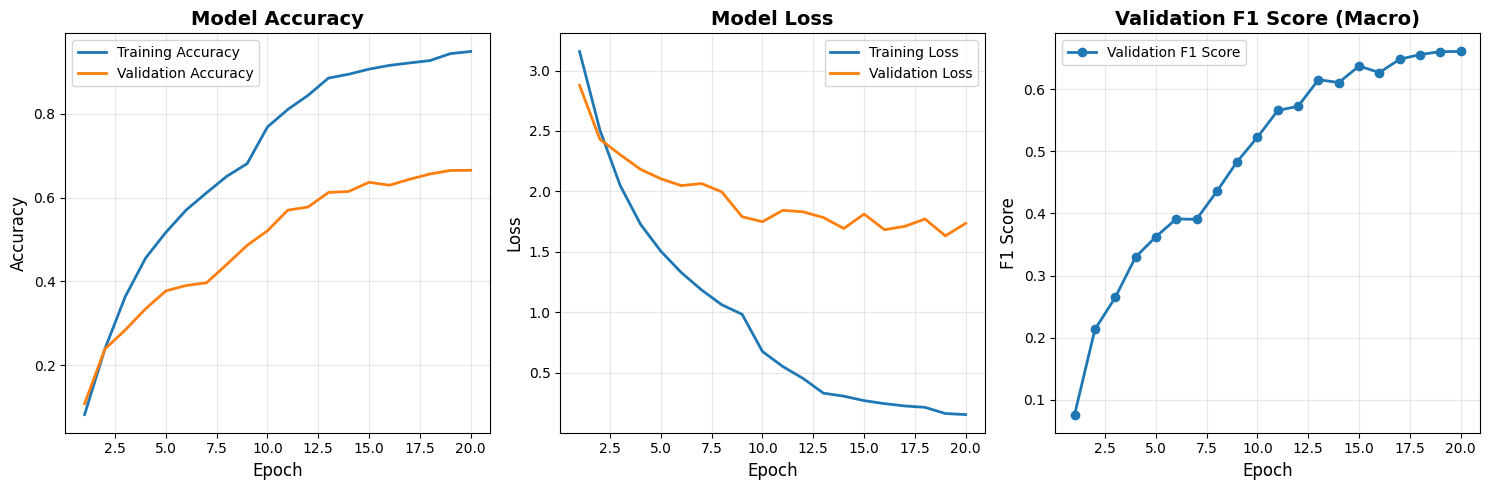

In [11]:
# Cell 9 - Plot training history
# Combine histories from both training stages
def combine_histories(h1, h2):
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history.get(k, [])
    for k in h2.history:
        if k not in history:
            history[k] = h2.history[k]
    return history

combined_hist = combine_histories(history1, history2)
f1_all = (f1_callback.f1s if hasattr(f1_callback, 'f1s') else []) + (f1_callback2.f1s if hasattr(f1_callback2, 'f1s') else [])

# Plot accuracy & loss
epochs_range = range(1, len(combined_hist['accuracy']) + 1)

plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 3, 1)
plt.plot(epochs_range, combined_hist['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, combined_hist['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 3, 2)
plt.plot(epochs_range, combined_hist['loss'], label='Training Loss', linewidth=2)
plt.plot(epochs_range, combined_hist['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# F1 score plot
plt.subplot(1, 3, 3)
plt.plot(range(1, len(f1_all) + 1), f1_all, marker='o', linewidth=2, label='Validation F1 Score')
plt.title('Validation F1 Score (Macro)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

507/507 ━━━━━━━━━━━━━━━━━━━━ 181s 357ms/step
Classification report (validation):
              precision    recall  f1-score   support

           A     0.9205    0.7717    0.8395       600
           B     0.7693    0.8617    0.8129       600
           C     0.9756    0.8650    0.9170       600
           D     0.8697    0.8567    0.8631       600
           E     0.5493    0.8917    0.6798       600
           F     0.9043    0.9917    0.9459       600
           G     0.8060    0.8933    0.8474       600
           H     0.8811    0.9383    0.9088       600
           I     0.8582    0.4033    0.5488       600
           J     0.7816    0.7633    0.7723       600
           K     0.9172    0.8867    0.9017       600
           L     0.9570    0.9633    0.9601       600
           M     0.5112    0.8383    0.6351       600
           N     0.6325    0.3183    0.4235       600
           O     0.7967    0.6533    0.7179       600
           P     0.5713    0.8817    0.6933       600


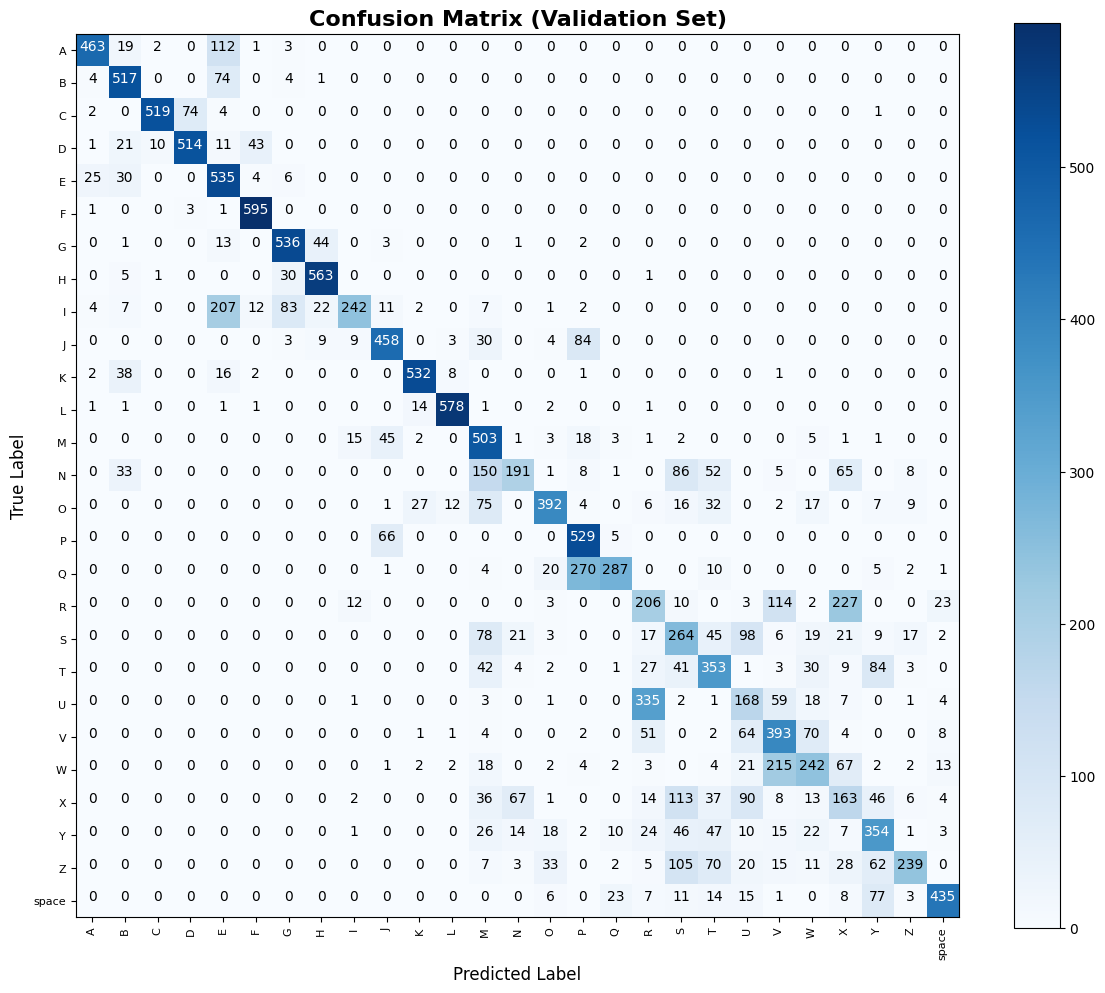

In [12]:
# Cell 10 - Predict on validation set and show classification report + confusion matrix
val_preds_prob = model.predict(validation_generator, verbose=1)
val_preds = np.argmax(val_preds_prob, axis=1)
val_true = validation_generator.classes
class_labels = list(train_generator.class_indices.keys())

print("Classification report (validation):")
print(classification_report(val_true, val_preds, target_names=class_labels, digits=4))

# Confusion matrix
cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Validation Set)", fontsize=16, fontweight='bold')
plt.colorbar()

# Add text annotations
threshold = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > threshold else "black")

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(ticks=np.arange(len(class_labels)), labels=class_labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(len(class_labels)), labels=class_labels, fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Cell 11 - Save model and class indices
model.save("asl_squeezenet_final.h5")
print("Saved model to asl_squeezenet_final.h5")

# Save class indices mapping
with open("class_indices_squeezenet.json", "w") as f:
    json.dump(train_generator.class_indices, f)
print("Saved class indices to class_indices_squeezenet.json")

Saved model to asl_squeezenet_final.h5
Saved class indices to class_indices_squeezenet.json


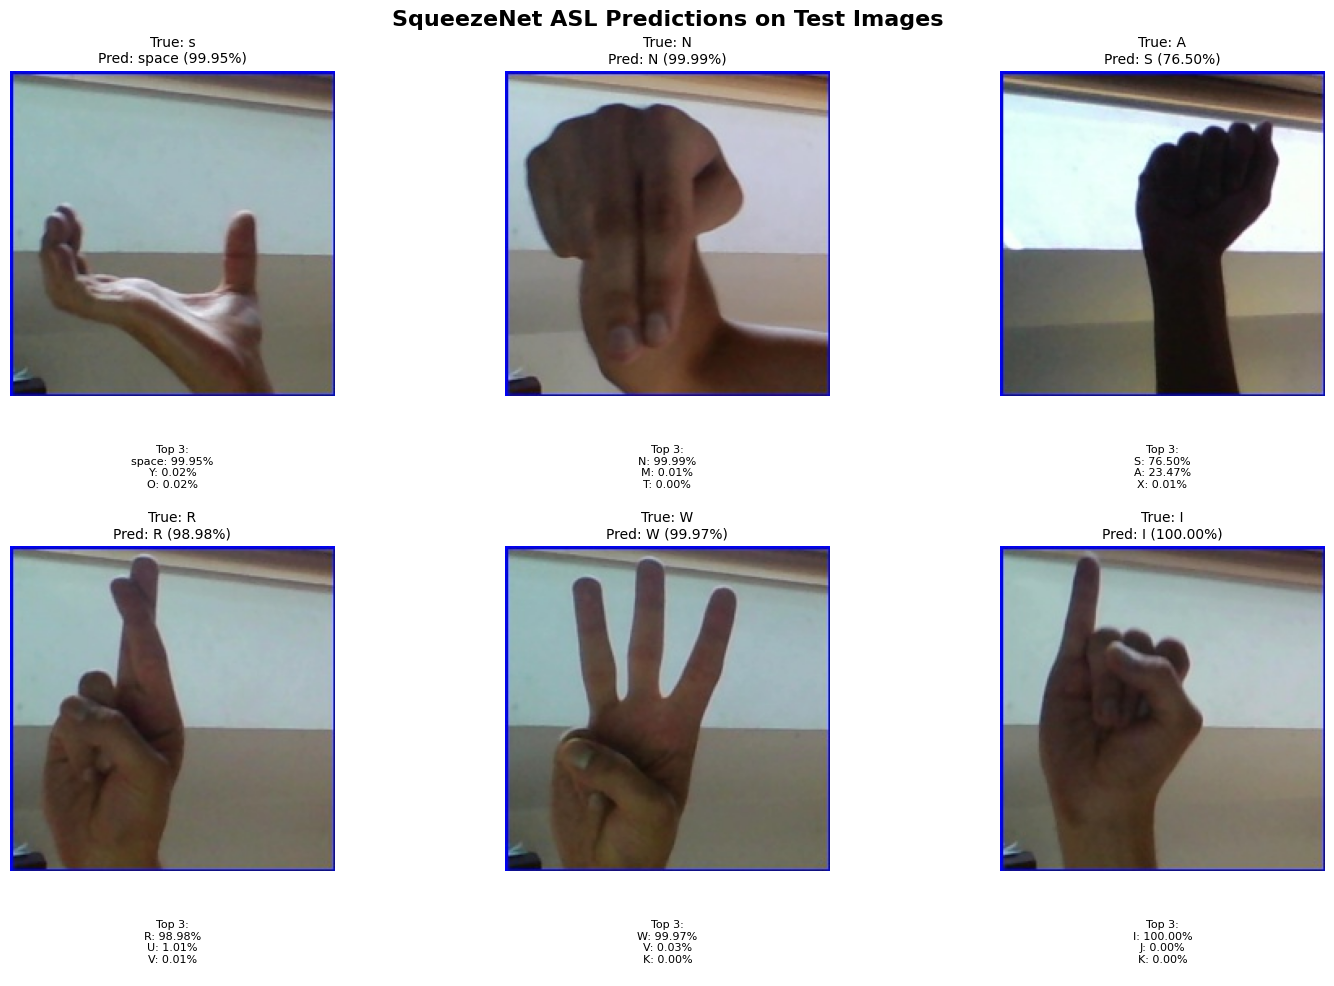

In [14]:
# Cell 12 - Predict on test images
import glob
from tensorflow.keras.preprocessing import image

# Get test images
test_img_paths = []
for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            test_img_paths.append(os.path.join(root, file))

if len(test_img_paths) == 0:
    raise RuntimeError("No test images found in TEST_DIR. Check TEST_DIR path.")

# Predict on 6 random test images
random.seed(SEED)
sample_paths = random.sample(test_img_paths, k=min(6, len(test_img_paths)))

plt.figure(figsize=(15, 10))
for i, p in enumerate(sample_paths):
    # Load and preprocess image
    img = image.load_img(p, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = squeezenet_preprocess(x)  # Use SqueezeNet preprocessing
    
    # Predict
    preds = model.predict(x, verbose=0)[0]
    top_idx = np.argmax(preds)
    top_prob = preds[top_idx]
    pred_class = class_labels[top_idx]
    
    # Get top 3 predictions
    top_3_indices = np.argsort(preds)[-3:][::-1]
    top_3_probs = preds[top_3_indices]
    top_3_classes = [class_labels[idx] for idx in top_3_indices]
    
    # Display
    plt.subplot(2, 3, i+1)
    plt.imshow((image.load_img(p)).convert('RGB'))
    plt.title(f"True: {os.path.basename(p)[0]}\nPred: {pred_class} ({top_prob:.2%})", fontsize=10)
    
    # Add top 3 predictions as text
    pred_text = "Top 3:\n"
    for cls, prob in zip(top_3_classes, top_3_probs):
        pred_text += f"{cls}: {prob:.2%}\n"
    plt.text(0.5, -0.15, pred_text, transform=plt.gca().transAxes,
             fontsize=8, ha='center', va='top')
    
    plt.axis('off')

plt.suptitle("SqueezeNet ASL Predictions on Test Images", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Cell 13 - Model evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate additional metrics
val_accuracy = accuracy_score(val_true, val_preds)
val_precision = precision_score(val_true, val_preds, average='macro')
val_recall = recall_score(val_true, val_preds, average='macro')
val_f1 = f1_score(val_true, val_preds, average='macro')

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1 Score:  {val_f1:.4f}")
print("="*60)


MODEL EVALUATION METRICS
Validation Accuracy:  0.6649
Validation Precision: 0.6902
Validation Recall:    0.6649
Validation F1 Score:  0.6611



Example prediction:


Image: A1.jpg
Predicted Sign: A
Confidence: 99.82%

Top 5 predictions:
  1. A: 99.82%
  2. E: 0.18%
  3. C: 0.00%
  4. O: 0.00%
  5. X: 0.00%


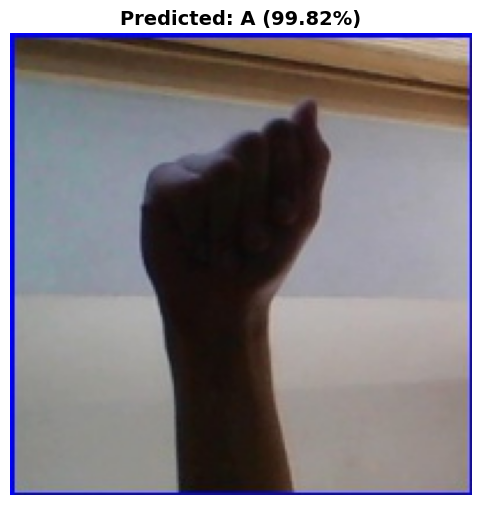

In [16]:
# Cell 14 - Single image prediction function
def predict_asl_sign(img_path, model_path="asl_squeezenet_final.h5", 
                    class_indices_path="class_indices_squeezenet.json"):
    """
    Predict ASL sign from a single image using the trained SqueezeNet model.
    
    Args:
        img_path: Path to the image file
        model_path: Path to saved model
        class_indices_path: Path to class indices JSON file
        
    Returns:
        predicted_class: Predicted ASL sign
        confidence: Confidence score
        all_predictions: Dictionary of all class predictions
    """
    
    # Load model and class indices
    model = keras.models.load_model(model_path)
    
    with open(class_indices_path, "r") as f:
        class_indices = json.load(f)
    
    index_to_class = {v: k for k, v in class_indices.items()}
    
    # Load and preprocess image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = squeezenet_preprocess(x)
    
    # Predict
    predictions = model.predict(x, verbose=0)[0]
    
    # Get top prediction
    top_idx = np.argmax(predictions)
    predicted_class = index_to_class[top_idx]
    confidence = predictions[top_idx]
    
    # Get all predictions sorted
    all_predictions = {}
    for idx, prob in enumerate(predictions):
        all_predictions[index_to_class[idx]] = float(prob)
    
    # Sort by probability
    all_predictions = dict(sorted(all_predictions.items(), 
                                  key=lambda x: x[1], reverse=True))
    
    return predicted_class, confidence, all_predictions

# Example usage
print("\nExample prediction:")
example_img = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train/A/A1.jpg"
pred_class, confidence, all_preds = predict_asl_sign(example_img)

print(f"Image: {os.path.basename(example_img)}")
print(f"Predicted Sign: {pred_class}")
print(f"Confidence: {confidence:.2%}")
print("\nTop 5 predictions:")
for i, (cls, prob) in enumerate(list(all_preds.items())[:5]):
    print(f"  {i+1}. {cls}: {prob:.2%}")

# Display the example image
img = mpimg.imread(example_img)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.2%})", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [17]:
# Cell 15 - Model size comparison and final summary
import tensorflow as tf

# Calculate model size
def get_model_size(model):
    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
    total_params = trainable_params + non_trainable_params
    return total_params, trainable_params, non_trainable_params

total_params, trainable_params, non_trainable_params = get_model_size(model)

print("\n" + "="*60)
print("SQUEEZENET MODEL SUMMARY")
print("="*60)
print(f"Total Parameters:       {total_params:,}")
print(f"Trainable Parameters:   {trainable_params:,}")
print(f"Non-trainable Parameters: {non_trainable_params:,}")
print(f"Input Size:             {IMG_SIZE}")
print(f"Number of Classes:      {num_classes}")
print(f"Training Samples:       {train_generator.samples:,}")
print(f"Validation Samples:     {validation_generator.samples:,}")
print("="*60)


SQUEEZENET MODEL SUMMARY
Total Parameters:       736,347
Trainable Parameters:   615,931
Non-trainable Parameters: 120,416
Input Size:             (227, 227)
Number of Classes:      27
Training Samples:       64,800
Validation Samples:     16,200
